# HydroGraphNet — Adaptive Physics-Constrained Loss Scheduling

**Research Paper Implementation Notebook**

_SRM Institute of Science and Technology — Final Semester Major Project_

---

### What This Notebook Does

Runs **three training experiments** and generates **publication-quality figures** for the conference paper:

| Experiment | Strategy | Description |
|---|---|---|
| EXP-1 | **Fixed** | Baseline — λ_phy = 1.0 throughout (original HydroGraphNet) |
| EXP-2 | **Linear Warm-up** | λ_phy: 0.01 → 1.0 over T_warmup epochs |
| EXP-3 | **Gradient Norm Balancing** | λ_phy auto-adjusted so ‖∇L_phy‖ ≈ ‖∇L_MSE‖ |

### Steps
1. Run each cell **top to bottom** (Shift+Enter)
2. Cells 1–5 install everything (~5–8 min, one-time)
3. Experiments each take **~15–25 min** on Colab T4 GPU
4. Figures auto-save to `figures/` and display inline

> **Make sure you have GPU enabled**: Runtime → Change runtime type → T4 GPU


---
## 🔵 CELL 1 — Check GPU & Mount Google Drive


In [ ]:
import subprocess, sys, os
import torch

# --- GPU check ---
try:
    gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if gpu_info.returncode == 0:
        print('GPU detected:')
        for line in gpu_info.stdout.split('\n')[:10]:
            print(' ', line)
    else:
        print('WARNING: No GPU found. Go to Runtime → Change runtime type → GPU.')
except FileNotFoundError:
    print('WARNING: nvidia-smi not found. Make sure GPU is enabled in Colab.')

print(f'\nPyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name: {torch.cuda.get_device_name(0)}')
    print(f'CUDA version: {torch.version.cuda}')

# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# *** Paths — all outputs go directly to Drive so they survive session resets ***
DATA_DIR  = '/content/drive/MyDrive/HydroGraphNet_Data'     # extracted dataset
DRIVE_ZIP = '/content/drive/MyDrive/HydroGraphNet.zip'      # uploaded zip
SAVE_DIR  = '/content/drive/MyDrive/HydroGraphNet_Results'  # CSVs + figures saved here

os.makedirs(DATA_DIR,  exist_ok=True)
os.makedirs(SAVE_DIR,  exist_ok=True)

print(f'\nData directory    : {DATA_DIR}')
print(f'Zip path          : {DRIVE_ZIP}')
print(f'Results directory : {SAVE_DIR}  ← outputs saved here during training')



---
## 🔵 CELL 2 — Install PyTorch Geometric

> This takes ~3–5 minutes. Run once per session.


In [2]:
import torch
TORCH_VER  = torch.__version__.split('+')[0]
CUDA_STR   = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'
CUDA_SHORT = 'cu' + torch.version.cuda.split('.')[0] + torch.version.cuda.split('.')[1] \
             if torch.cuda.is_available() else 'cpu'

print(f'Installing PyG for torch={TORCH_VER}, cuda={CUDA_SHORT}')

# Install PyTorch Geometric + sparse extensions
!pip install -q torch_geometric
!pip install -q torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{TORCH_VER}+{CUDA_SHORT}.html

print('Done.')


Installing PyG for torch=2.10.0, cuda=cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 44.5 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 24.2 MB/s eta 0:00:0000:0100:01
Done.


---
## 🔵 CELL 3 — Install NVIDIA PhysicsNeMo & Other Dependencies

> ~3 minutes


In [3]:
# Install NVIDIA PhysicsNeMo (contains MeshGraphKAN model + HydroGraphDataset)
!pip install -q "nvidia-physicsnemo" 2>/dev/null || \
 pip install -q git+https://github.com/NVIDIA/physicsnemo.git

# Other dependencies
!pip install -q hydra-core omegaconf wandb termcolor scipy networkx tqdm mlflow

# Verify key imports
import importlib
for pkg in ['physicsnemo', 'torch_geometric', 'wandb', 'hydra']:
    try:
        importlib.import_module(pkg)
        print(f'  OK  {pkg}')
    except ImportError as e:
        print(f'  FAIL {pkg}: {e}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 82.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 107.4 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 101.2 MB/s eta 0:00:0000:010:01
   ━━━━

---
## 🔵 CELL 4 — Write All Project Files

This cell writes `utils.py`, `adaptive_physics_scheduler.py`, `train_colab.py`,  
and the Hydra config — everything the experiments need.


In [4]:
import os
os.makedirs('/content/conf', exist_ok=True)
os.makedirs('/content/figures', exist_ok=True)

# ============================================================
# utils.py  — physics loss
# ============================================================
UTILS_PY = '''
import torch
import torch.nn.functional as F

def compute_physics_loss(pred, physics_data, graph, delta_t=1200.0):
    unique_ids = torch.unique(graph.batch)
    predicted_diff = pred[:, 1]
    physics_losses = []
    for uid in unique_ids:
        mask = graph.batch == uid
        pred_diff_sum = predicted_diff[mask].sum()
        idx = (unique_ids == uid).nonzero(as_tuple=False).item()
        past_volume_norm    = physics_data["past_volume"][idx]
        future_volume_norm  = physics_data["future_volume"][idx]
        denorm_avg_inflow   = physics_data["avg_inflow"][idx]
        denorm_avg_precip   = physics_data["avg_precipitation"][idx]
        denorm_next_inflow  = physics_data["next_inflow"][idx]
        denorm_next_precip  = physics_data["next_precip"][idx]
        volume_mean         = physics_data["volume_mean"][idx]
        volume_std          = physics_data["volume_std"][idx]
        num_nodes           = physics_data["num_nodes"][idx]
        area_sum            = physics_data["area_sum"][idx]
        infiltration_area_sum = physics_data["infiltration_area_sum"][idx]
        past_volume_denorm   = past_volume_norm * volume_std + num_nodes * volume_mean
        future_volume_denorm = future_volume_norm * volume_std + num_nodes * volume_mean
        pred_total_volume    = past_volume_denorm + volume_std * pred_diff_sum
        new_precip_term      = denorm_avg_precip * infiltration_area_sum
        new_next_precip_term = denorm_next_precip * infiltration_area_sum
        term1 = (F.relu((pred_total_volume - (past_volume_denorm + delta_t * (denorm_avg_inflow + new_precip_term))) / area_sum)) ** 2
        term2 = (F.relu((future_volume_denorm - pred_total_volume - delta_t * (denorm_next_inflow + new_next_precip_term)) / area_sum)) ** 2
        physics_losses.append(term1 + term2)
    if physics_losses:
        return torch.stack(physics_losses).mean()
    return torch.tensor(0.0, device=pred.device)
'''

with open('/content/utils.py', 'w') as f:
    f.write(UTILS_PY)
print('Wrote utils.py')

# ============================================================
# adaptive_physics_scheduler.py
# ============================================================
SCHEDULER_PY = '''
import math, logging
logger = logging.getLogger(__name__)

class BasePhysicsScheduler:
    def __init__(self, lambda_init=0.01, lambda_min=1e-3, lambda_max=10.0):
        self.lambda_phy = lambda_init
        self.lambda_min = lambda_min
        self.lambda_max = lambda_max
        self.history = []
    def _clip(self, v):
        return max(self.lambda_min, min(self.lambda_max, v))
    def step(self, **kwargs):
        raise NotImplementedError
    def log_epoch(self, epoch, rho=None):
        self.history.append({"epoch": epoch, "lambda_phy": self.lambda_phy, "rho": rho})

class LinearWarmupScheduler(BasePhysicsScheduler):
    """Linearly ramps lambda from lambda_init to lambda_max over T_warmup epochs."""
    def __init__(self, lambda_init=0.01, lambda_max=1.0, T_warmup=20, **kw):
        super().__init__(lambda_init=lambda_init, lambda_max=lambda_max)
        self.T_warmup = T_warmup
        self._epoch = 0
    def step(self, **kw):
        self._epoch += 1
        self.lambda_phy = self._clip(self.lambda_max * min(1.0, self._epoch / self.T_warmup))
        self.log_epoch(self._epoch)
        return self.lambda_phy

class GradientNormBalancer(BasePhysicsScheduler):
    """Keeps ||grad L_phy|| / ||grad L_mse|| near 1."""
    def __init__(self, lambda_init=0.1, lambda_min=1e-3, lambda_max=10.0,
                 eps=1e-8, smooth=0.9, **kw):
        super().__init__(lambda_init=lambda_init, lambda_min=lambda_min, lambda_max=lambda_max)
        self.eps = eps
        self.smooth = smooth
        self._ema_mse = None
        self._ema_phy = None
        self._epoch = 0
    def step(self, g_mse=0.0, g_phy=0.0, **kw):
        self._epoch += 1
        if self._ema_mse is None:
            self._ema_mse, self._ema_phy = g_mse, g_phy
        else:
            self._ema_mse = self.smooth * self._ema_mse + (1 - self.smooth) * g_mse
            self._ema_phy = self.smooth * self._ema_phy + (1 - self.smooth) * g_phy
        rho = self._ema_phy / (self._ema_mse + self.eps)
        self.lambda_phy = self._clip(self.lambda_phy * (self._ema_mse / (self._ema_phy + self.eps)))
        self.log_epoch(self._epoch, rho=rho)
        return self.lambda_phy

class FixedScheduler(BasePhysicsScheduler):
    def __init__(self, lambda_phy=1.0, **kw):
        super().__init__(lambda_init=lambda_phy, lambda_max=lambda_phy)
        self._epoch = 0
    def step(self, **kw):
        self._epoch += 1
        self.log_epoch(self._epoch)
        return self.lambda_phy

def build_scheduler(strategy, **kwargs):
    registry = {
        "fixed": FixedScheduler,
        "linear_warmup": LinearWarmupScheduler,
        "gnb": GradientNormBalancer,
    }
    if strategy not in registry:
        raise ValueError(f"Unknown strategy: {strategy}")
    return registry[strategy](**kwargs)
'''

with open('/content/adaptive_physics_scheduler.py', 'w') as f:
    f.write(SCHEDULER_PY)
print('Wrote adaptive_physics_scheduler.py')
print('All helper files written.')


Wrote utils.py
Wrote adaptive_physics_scheduler.py
All helper files written.


---
## 🔵 CELL 5 — Write Training Script (`train_colab.py`)


In [25]:
TRAIN_COLAB = r'''
"""
train_colab.py
Colab-friendly training script for HydroGraphNet with adaptive physics loss.
Uses argparse (no Hydra) so it runs cleanly in Colab.
Saves per-epoch metrics to a CSV for figure generation.
"""
import argparse, csv, os, sys, time
import torch
import torch.nn as nn
import torch_geometric as pyg
import wandb
from torch_geometric.loader import DataLoader as PyGDataLoader

sys.path.insert(0, "/content")
from utils import compute_physics_loss
from adaptive_physics_scheduler import build_scheduler

from physicsnemo.datapipes.gnn.hydrographnet_dataset import HydroGraphDataset
from physicsnemo.models.meshgraphnet.meshgraphkan import MeshGraphKAN


def get_args():
    p = argparse.ArgumentParser()
    p.add_argument("--data_dir",      default="/content/data")
    p.add_argument("--exp_name",      default="fixed")
    p.add_argument("--epochs",        type=int,   default=15)
    p.add_argument("--num_samples",   type=int,   default=15)
    p.add_argument("--n_time_steps",  type=int,   default=2)
    p.add_argument("--lr",            type=float, default=1e-4)
    p.add_argument("--schedule",      default="fixed",
                   choices=["fixed", "linear_warmup", "gnb"])
    p.add_argument("--lambda_init",   type=float, default=1.0)
    p.add_argument("--lambda_max",    type=float, default=1.0)
    p.add_argument("--warmup_epochs", type=int,   default=10)
    p.add_argument("--wandb_mode",    default="disabled")
    p.add_argument("--use_physics",   action="store_true", default=True)
    p.add_argument("--delta_t",       type=float, default=1200.0)
    p.add_argument("--out_dir",       default="/content/outputs")
    return p.parse_args()


def collate_fn(batch):
    if isinstance(batch[0], tuple):
        graphs, physics_list = zip(*batch)
        bg = pyg.data.Batch.from_data_list(graphs)
        pd = {}
        for key in physics_list[0].keys():
            pd[key] = torch.tensor([d[key] for d in physics_list], dtype=torch.float)
        return bg, pd
    return pyg.data.Batch.from_data_list(batch)


def grad_norm_for(loss, model, optimizer):
    optimizer.zero_grad()
    loss.backward(retain_graph=True)
    norm = sum(p.grad.data.norm(2).item() ** 2
               for p in model.parameters() if p.grad is not None) ** 0.5
    return norm


def main():
    args = get_args()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[{args.exp_name}] device={device}  schedule={args.schedule}")

    exp_out = os.path.join(args.out_dir, args.exp_name)
    os.makedirs(exp_out, exist_ok=True)
    csv_path = os.path.join(exp_out, "metrics.csv")

    wandb.init(project="HydroGraphNet", name=args.exp_name,
               mode=args.wandb_mode, config=vars(args))

    print("Loading dataset...")
    dataset = HydroGraphDataset(
        name="hydrograph_dataset",
        data_dir=args.data_dir,
        prefix="M80",
        num_samples=args.num_samples,
        n_time_steps=args.n_time_steps,
        k=4,
        noise_type="none",
        noise_std=0.01,
        hydrograph_ids_file="train.txt",
        split="train",
        return_physics=args.use_physics,
    )
    loader = PyGDataLoader(
        dataset, batch_size=1, shuffle=True, num_workers=2, collate_fn=collate_fn,
    )
    print(f"Dataset size: {len(dataset)} samples  |  {len(loader)} batches/epoch")

    model = MeshGraphKAN(
        input_dim_nodes=16, input_dim_edges=3, output_dim=2,
    ).to(device)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=1e-4)
    lr_scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=lambda e: 0.9999979 ** e)

    phy_scheduler = build_scheduler(
        args.schedule,
        lambda_init=args.lambda_init,
        lambda_max=args.lambda_max,
        lambda_phy=args.lambda_init,
        T_warmup=args.warmup_epochs,
    )
    lambda_phy = phy_scheduler.lambda_phy

    CSV_COLS = ["epoch", "loss_total", "loss_mse", "loss_physics",
                "lambda_phy", "grad_norm_mse", "grad_norm_phy", "rho",
                "rmse_depth", "rmse_volume", "r2_depth", "epoch_time_s"]
    with open(csv_path, "w", newline="") as f:
        csv.DictWriter(f, fieldnames=CSV_COLS).writeheader()

    for epoch in range(args.epochs):
        model.train()
        t0 = time.time()

        ep_losses, ep_mse, ep_phy = [], [], []
        ep_preds, ep_targets = [], []
        ep_g_mse, ep_g_phy = [], []

        for batch in loader:
            if args.use_physics:
                graph, phy_data = batch
                graph = graph.to(device)
                phy_data = {k: v.to(device) for k, v in phy_data.items()}
            else:
                graph = batch.to(device)
                phy_data = None

            pred = model(graph.x, graph.edge_attr, graph)
            mse_loss = criterion(pred, graph.y)

            phy_loss = torch.tensor(0.0, device=device)
            if args.use_physics and phy_data is not None:
                phy_loss = compute_physics_loss(pred, phy_data, graph, args.delta_t)

            total_loss = mse_loss + lambda_phy * phy_loss

            g_mse_val, g_phy_val = 0.0, 0.0
            if args.schedule == "gnb" and args.use_physics and phy_data is not None:
                g_mse_val = grad_norm_for(
                    criterion(model(graph.x, graph.edge_attr, graph), graph.y),
                    model, optimizer)
                pred2 = model(graph.x, graph.edge_attr, graph)
                g_phy_val = grad_norm_for(
                    compute_physics_loss(pred2, phy_data, graph, args.delta_t),
                    model, optimizer)

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            lr_scheduler.step()

            ep_losses.append(total_loss.detach().item())
            ep_mse.append(mse_loss.detach().item())
            ep_phy.append(phy_loss.detach().item())
            ep_preds.append(pred.detach().cpu())
            ep_targets.append(graph.y.detach().cpu())
            ep_g_mse.append(g_mse_val)
            ep_g_phy.append(g_phy_val)

        # Epoch-level metrics (torch already imported at top — no import here)
        all_pred = torch.cat(ep_preds, 0)
        all_tgt  = torch.cat(ep_targets, 0)
        rmse_d = (((all_pred[:,0] - all_tgt[:,0])**2).mean()).sqrt().item()
        rmse_v = (((all_pred[:,1] - all_tgt[:,1])**2).mean()).sqrt().item()
        ss_res = ((all_tgt[:,0] - all_pred[:,0])**2).sum()
        ss_tot = ((all_tgt[:,0] - all_tgt[:,0].mean())**2).sum()
        r2_d   = (1 - ss_res / (ss_tot + 1e-8)).item()

        avg_g_mse = sum(ep_g_mse) / max(len(ep_g_mse), 1)
        avg_g_phy = sum(ep_g_phy) / max(len(ep_g_phy), 1)
        rho = avg_g_phy / (avg_g_mse + 1e-8) if avg_g_mse > 0 else 0.0

        lambda_phy = phy_scheduler.step(
            g_mse=avg_g_mse, g_phy=avg_g_phy,
            val_loss=sum(ep_losses)/len(ep_losses))

        epoch_time = time.time() - t0
        row = {
            "epoch": epoch,
            "loss_total":   sum(ep_losses)/len(ep_losses),
            "loss_mse":     sum(ep_mse)/len(ep_mse),
            "loss_physics": sum(ep_phy)/len(ep_phy),
            "lambda_phy":   lambda_phy,
            "grad_norm_mse": avg_g_mse,
            "grad_norm_phy": avg_g_phy,
            "rho":          rho,
            "rmse_depth":   rmse_d,
            "rmse_volume":  rmse_v,
            "r2_depth":     r2_d,
            "epoch_time_s": epoch_time,
        }
        with open(csv_path, "a", newline="") as f:
            csv.DictWriter(f, fieldnames=CSV_COLS).writerow(row)

        wandb.log({"epoch": epoch,
                   "loss/total": row["loss_total"], "loss/mse": row["loss_mse"],
                   "loss/physics": row["loss_physics"],
                   "physics/lambda_phy": lambda_phy, "physics/rho": rho,
                   "metrics/rmse_depth": rmse_d, "metrics/r2": r2_d})

        print(f"  Epoch {epoch:02d}/{args.epochs-1} | "
              f"loss={row['loss_total']:.4e} | mse={row['loss_mse']:.4e} | "
              f"phy={row['loss_physics']:.4e} | lambda={lambda_phy:.4f} | "
              f"rho={rho:.3f} | RMSE_d={rmse_d:.4f} | R2={r2_d:.3f} | t={epoch_time:.1f}s")

    wandb.finish()
    print(f"\nCSV saved: {csv_path}")
    return csv_path

if __name__ == "__main__":
    main()
'''

with open('/content/train_colab.py', 'w') as f:
    f.write(TRAIN_COLAB)
print('Wrote train_colab.py')
print()
print('File summary:')
for fn in ['utils.py', 'adaptive_physics_scheduler.py', 'train_colab.py']:
    path = f'/content/{fn}'
    size = os.path.getsize(path)
    print(f'  {fn}: {size} bytes')


Wrote train_colab.py

File summary:
  utils.py: 1943 bytes
  adaptive_physics_scheduler.py: 2793 bytes
  train_colab.py: 8437 bytes


---
## 🔵 CELL 6 — Load Dataset from Google Drive

This cell handles three scenarios automatically:

1. **Already unzipped** — files exist in `DATA_DIR`, proceeds immediately (every session after first)
2. **Zip found in Drive** — unzips `HydroGraphNet.zip` → `HydroGraphNet_Data/` (first session only)
3. **Nothing found** — prompts you to upload the zip manually

**One-time setup:** Upload your zipped data as `HydroGraphNet.zip` to your **Google Drive root**.


In [6]:
import os, sys, zipfile
sys.path.insert(0, '/content')

# DATA_DIR and DRIVE_ZIP are set in Cell 1.
# Override here only if you skipped Cell 1:
# DATA_DIR  = '/content/drive/MyDrive/HydroGraphNet_Data'
# DRIVE_ZIP = '/content/drive/MyDrive/HydroGraphNet.zip'

REQUIRED_FILES = ['M80_XY.txt', 'M80_CA.txt', 'M80_CE.txt', 'train.txt', 'test.txt']

def files_ready():
    return all(os.path.exists(os.path.join(DATA_DIR, f)) for f in REQUIRED_FILES)

# ── Scenario 1: files already extracted ──────────────────────────────────
if files_ready():
    print('✓ Data already extracted — skipping.')

# ── Scenario 2: zip exists in Drive → extract it ─────────────────────────
elif os.path.exists(DRIVE_ZIP):
    zip_gb = os.path.getsize(DRIVE_ZIP) / 1e9
    print(f'Found {DRIVE_ZIP}  ({zip_gb:.2f} GB)')
    print(f'Extracting to {DATA_DIR} ...')
    os.makedirs(DATA_DIR, exist_ok=True)
    with zipfile.ZipFile(DRIVE_ZIP, 'r') as zf:
        members = zf.namelist()
        total = len(members)
        for i, member in enumerate(members):
            zf.extract(member, DATA_DIR)
            if total > 0 and (i + 1) % max(1, total // 10) == 0:
                print(f'  {(i + 1) * 100 // total}% ...', flush=True)
    print('Extraction complete!')

# ── Scenario 3: nothing found → manual upload ────────────────────────────
else:
    print(f'No data found at {DATA_DIR}')
    print(f'No zip found at  {DRIVE_ZIP}')
    print()
    print('Upload your HydroGraphNet.zip when prompted.')
    print('It will be saved to Drive and extracted automatically.')
    print('(One-time only — future sessions will skip this step.)')
    print()
    from google.colab import files as colab_files
    uploaded = colab_files.upload()
    for fname, data in uploaded.items():
        if fname.endswith('.zip'):
            dest = DRIVE_ZIP
        else:
            dest = os.path.join(DATA_DIR, fname)
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        with open(dest, 'wb') as fh:
            fh.write(data)
        print(f'Saved to Drive: {dest}')
        if fname.endswith('.zip'):
            print('Extracting ...')
            os.makedirs(DATA_DIR, exist_ok=True)
            with zipfile.ZipFile(dest, 'r') as zf:
                members = zf.namelist()
                total = len(members)
                for i, member in enumerate(members):
                    zf.extract(member, DATA_DIR)
                    if total > 0 and (i + 1) % max(1, total // 10) == 0:
                        print(f'  {(i + 1) * 100 // total}% ...', flush=True)
            print('Extraction complete!')

# ── Final verification ────────────────────────────────────────────────────
print()
all_ok = True
for fn in REQUIRED_FILES:
    path = os.path.join(DATA_DIR, fn)
    if os.path.exists(path):
        print(f'  OK  {fn}  ({os.path.getsize(path) // 1024} KB)')
    else:
        print(f'  MISSING  {fn}')
        all_ok = False

if all_ok:
    print('\nDataset ready!')
else:
    print('\nERROR: Some files still missing.')
    print('Check your zip structure — files must be at the top level, not inside a subfolder.')


Found /content/drive/MyDrive/HydroGraphNet.zip  (8.28 GB)
Extracting to /content/drive/MyDrive/HydroGraphNet_Data ...
  9% ...
  19% ...
  29% ...
  39% ...
  49% ...
  59% ...
  69% ...
  79% ...
  89% ...
  99% ...
Extraction complete!

  OK  M80_XY.txt  (168 KB)
  OK  M80_CA.txt  (78 KB)
  OK  M80_CE.txt  (71 KB)
  OK  train.txt  (2 KB)
  MISSING  test.txt

ERROR: Some files still missing.
Check your zip structure — files must be at the top level, not inside a subfolder.


---
## 🔵 CELL 7 — W&B Login (Optional)

Skip if you don't want W&B tracking. Results will still be saved to CSV.


In [ ]:
# Set to True to enable W&B tracking and get live loss curves
USE_WANDB = False

if USE_WANDB:
    import wandb
    wandb.login()   # paste your API key when prompted
    WANDB_MODE = 'online'
    print('W&B enabled. Dashboard: https://wandb.ai')
else:
    WANDB_MODE = 'disabled'
    print('W&B disabled. Metrics will be saved to CSV only.')

# ---- Experiment settings (adjust as needed) ----
EPOCHS      = 15      # 15 gives clear trends; increase to 30 for better results
NUM_SAMPLES = 15      # number of hydrograph scenarios to train on

# Outputs go directly to Google Drive — safe across session resets
# SAVE_DIR is set in Cell 1. Override here only if you skipped Cell 1:
# SAVE_DIR = '/content/drive/MyDrive/HydroGraphNet_Results'
OUT_DIR = f'{SAVE_DIR}/outputs'
FIG_DIR = f'{SAVE_DIR}/figures'

import os
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f'\nExperiment settings:')
print(f'  Epochs:      {EPOCHS}')
print(f'  Hydrographs: {NUM_SAMPLES}')
print(f'  W&B mode:    {WANDB_MODE}')
print(f'  CSVs → {OUT_DIR}')
print(f'  Figures → {FIG_DIR}')


---
## 🔴 CELL 8 — EXP-1: Baseline (Fixed λ = 1.0)

Reproduces the **original HydroGraphNet training strategy** with a constant physics loss weight.  
This is the **control experiment** — shows the gradient norm imbalance problem.

> **Expected time:** ~10–20 min on T4 GPU


In [26]:
print('='*60)
print('EXP-1: Baseline — Fixed λ_phy = 1.0')
print('='*60)

!python /content/train_colab.py \
    --data_dir {DATA_DIR} \
    --exp_name fixed \
    --epochs {EPOCHS} \
    --num_samples {NUM_SAMPLES} \
    --schedule fixed \
    --lambda_init 1.0 \
    --lambda_max 1.0 \
    --wandb_mode {WANDB_MODE} \
    --out_dir {OUT_DIR}

print('\nEXP-1 complete. CSV saved to:', OUT_DIR + '/fixed/metrics.csv')


EXP-1: Baseline — Fixed λ_phy = 1.0
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
[fixed] device=cuda  schedule=fixed
Loading dataset...
[INFO] Data directory /content/drive/MyDrive/HydroGraphNet_Data already exists. Skipping download.
Processing Hydrographs: 100% 15/15 [00:43<00:00,  2.91s/it]
Dataset size: 1206 samples  |  1206 batches/epoch
Model parameters: 2,318,722
  Epoch 00/14 | loss=1.5801e-03 | mse=1.3746e-03 | phy=2.0550e-04 | lambda=1.0000 | rho=0.000 | RMSE_d=0.0349 | R2=-1.395 | t=140.4s
  Epoch 01/14 | loss=5.5555e-04 | mse=5.4308e-04 | phy=1.2475e-05 | lambda=1.0000 | rho=0.000 | RMSE_d=0.0236 | R2=-0.092 | t=150.3s
  Epoch 02/14 | loss=5.0447e-04 | mse=4.9570e-04 | phy=8.7701e-06 | lambda=1.0000 | rho=0.000 | RMSE_d=0.0223 | R2=0.019 | t=151.3s
  Epoch 03/14 | loss=4.6594e-04 | mse=4.6009e-04 | phy=5.8542e-06 | lambda=1.0000 | rho=0.000 | RMSE_d=0.0214 | R2=0.102 | t=151.7s
  Epoch 04/14 |

---
## 🟡 CELL 9 — EXP-2: Linear Warm-up (λ: 0.01 → 1.0)

**Strategy 1** from the paper: λ_phy starts near-zero and ramps linearly over `warmup_epochs`.  
Prevents physics loss from dominating gradients in early training.

> **Expected time:** ~10–20 min on T4 GPU


In [27]:
print('='*60)
print('EXP-2: Linear Warm-up  λ: 0.01 → 1.0 over 10 epochs')
print('='*60)

!python /content/train_colab.py \
    --data_dir {DATA_DIR} \
    --exp_name linear_warmup \
    --epochs {EPOCHS} \
    --num_samples {NUM_SAMPLES} \
    --schedule linear_warmup \
    --lambda_init 0.01 \
    --lambda_max 1.0 \
    --warmup_epochs 10 \
    --wandb_mode {WANDB_MODE} \
    --out_dir {OUT_DIR}

print('\nEXP-2 complete. CSV saved to:', OUT_DIR + '/linear_warmup/metrics.csv')


EXP-2: Linear Warm-up  λ: 0.01 → 1.0 over 10 epochs
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
[linear_warmup] device=cuda  schedule=linear_warmup
Loading dataset...
[INFO] Data directory /content/drive/MyDrive/HydroGraphNet_Data already exists. Skipping download.
Processing Hydrographs: 100% 15/15 [00:50<00:00,  3.35s/it]
Dataset size: 1092 samples  |  1092 batches/epoch
Model parameters: 2,318,722
  Epoch 00/14 | loss=1.5162e-03 | mse=1.5139e-03 | phy=2.2696e-04 | lambda=0.1000 | rho=0.000 | RMSE_d=0.0365 | R2=-1.461 | t=127.4s
  Epoch 01/14 | loss=5.4857e-04 | mse=5.4756e-04 | phy=1.0181e-05 | lambda=0.2000 | rho=0.000 | RMSE_d=0.0238 | R2=-0.047 | t=136.3s
  Epoch 02/14 | loss=4.9750e-04 | mse=4.9618e-04 | phy=6.6262e-06 | lambda=0.3000 | rho=0.000 | RMSE_d=0.0224 | R2=0.072 | t=137.4s
  Epoch 03/14 | loss=4.8270e-04 | mse=4.8128e-04 | phy=4.7265e-06 | lambda=0.4000 | rho=0.000 | RMSE_d=0.0220 | R2=

---
## 🟢 CELL 10 — EXP-3: Gradient Norm Balancing (GNB)

**Strategy 2** from the paper: λ_phy is auto-adjusted each epoch so that  
`‖∇L_physics‖ ≈ ‖∇L_MSE‖` — the key novel contribution.

> **Note:** GNB runs 2 extra forward passes per batch for gradient norm computation,  
> so it takes ~2× longer per epoch than EXP-1/2.

> **Expected time:** ~20–40 min on T4 GPU


In [10]:
print('='*60)
print('EXP-3: Gradient Norm Balancing (GNB)')
print('='*60)

!python /content/train_colab.py \
    --data_dir {DATA_DIR} \
    --exp_name gnb \
    --epochs {EPOCHS} \
    --num_samples {NUM_SAMPLES} \
    --schedule gnb \
    --lambda_init 0.1 \
    --lambda_max 5.0 \
    --wandb_mode {WANDB_MODE} \
    --out_dir {OUT_DIR}

print('\nEXP-3 complete. CSV saved to:', OUT_DIR + '/gnb/metrics.csv')


EXP-3: Gradient Norm Balancing (GNB)
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
Traceback (most recent call last):
  File "/content/train_colab.py", line 250, in <module>
    main()
  File "/content/train_colab.py", line 73, in main
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
             ^^^^^
UnboundLocalError: cannot access local variable 'torch' where it is not associated with a value
sys:1: DeprecationWarning: builtin type swigvarlink has no __module__ attribute

EXP-3 complete. CSV saved to: /content/outputs/gnb/metrics.csv


---
## 🔵 CELL 11 — Verify & Preview Results


In [ ]:
import csv, os

# OUT_DIR is set in Cell 7 (Google Drive path). Override here only if needed:
# OUT_DIR = '/content/drive/MyDrive/HydroGraphNet_Results/outputs'

for exp in ['fixed', 'linear_warmup', 'gnb']:
    csv_path = f'{OUT_DIR}/{exp}/metrics.csv'
    if not os.path.exists(csv_path):
        print(f'  MISSING: {csv_path}')
        continue
    with open(csv_path) as f:
        rows = list(csv.DictReader(f))
    if not rows:
        print(f'  EMPTY: {csv_path}')
        continue
    last = rows[-1]
    print(f'{exp:15s}  epochs={len(rows)}  '
          f'loss={float(last["loss_total"]):.4e}  '
          f'mse={float(last["loss_mse"]):.4e}  '
          f'phy={float(last["loss_physics"]):.4e}  '
          f'rho={float(last["rho"]):.3f}  '
          f'lambda={float(last["lambda_phy"]):.4f}  '
          f'RMSE_d={float(last["rmse_depth"]):.4f}  '
          f'R2={float(last["r2_depth"]):.3f}')


---
## 🔵 CELL 12 — Generate All Paper Figures

Produces **7 publication-quality figures** in `figures/`  
including the combined **Fig 7 panel** for direct paper inclusion.


In [ ]:
import csv, math, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

matplotlib.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 13, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'legend.fontsize': 11, 'figure.dpi': 120, 'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# OUT_DIR and FIG_DIR are set in Cell 7 (pointing to Google Drive).
# Override here only if you skipped Cell 7:
# OUT_DIR = '/content/drive/MyDrive/HydroGraphNet_Results/outputs'
# FIG_DIR = '/content/drive/MyDrive/HydroGraphNet_Results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

COLORS = {'fixed': '#E63946', 'linear_warmup': '#2A9D8F', 'gnb': '#F4A261'}
LABELS = {'fixed': 'EXP-1: Fixed (λ=1.0)', 'linear_warmup': 'EXP-2: Warm-up', 'gnb': 'EXP-3: GNB'}
LS     = {'fixed': 'solid', 'linear_warmup': 'dashed', 'gnb': 'dotted'}

# ---- Load data ----
def load(exp):
    path = f'{OUT_DIR}/{exp}/metrics.csv'
    if not os.path.exists(path):
        return None
    d = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            for k, v in row.items():
                d.setdefault(k, [])
                try:
                    d[k].append(float(v))
                except:
                    d[k].append(float('nan'))
    return d

data = {e: load(e) for e in ['fixed', 'linear_warmup', 'gnb']}
data = {k: v for k, v in data.items() if v}
print(f'Loaded experiments: {list(data.keys())}')
for k, v in data.items():
    print(f'  {k}: {len(v.get("epoch", []))} epochs')
print(f'\nFigures will be saved to: {FIG_DIR}')


### Figure 1-2: Loss Curves & Gradient Ratio ρ


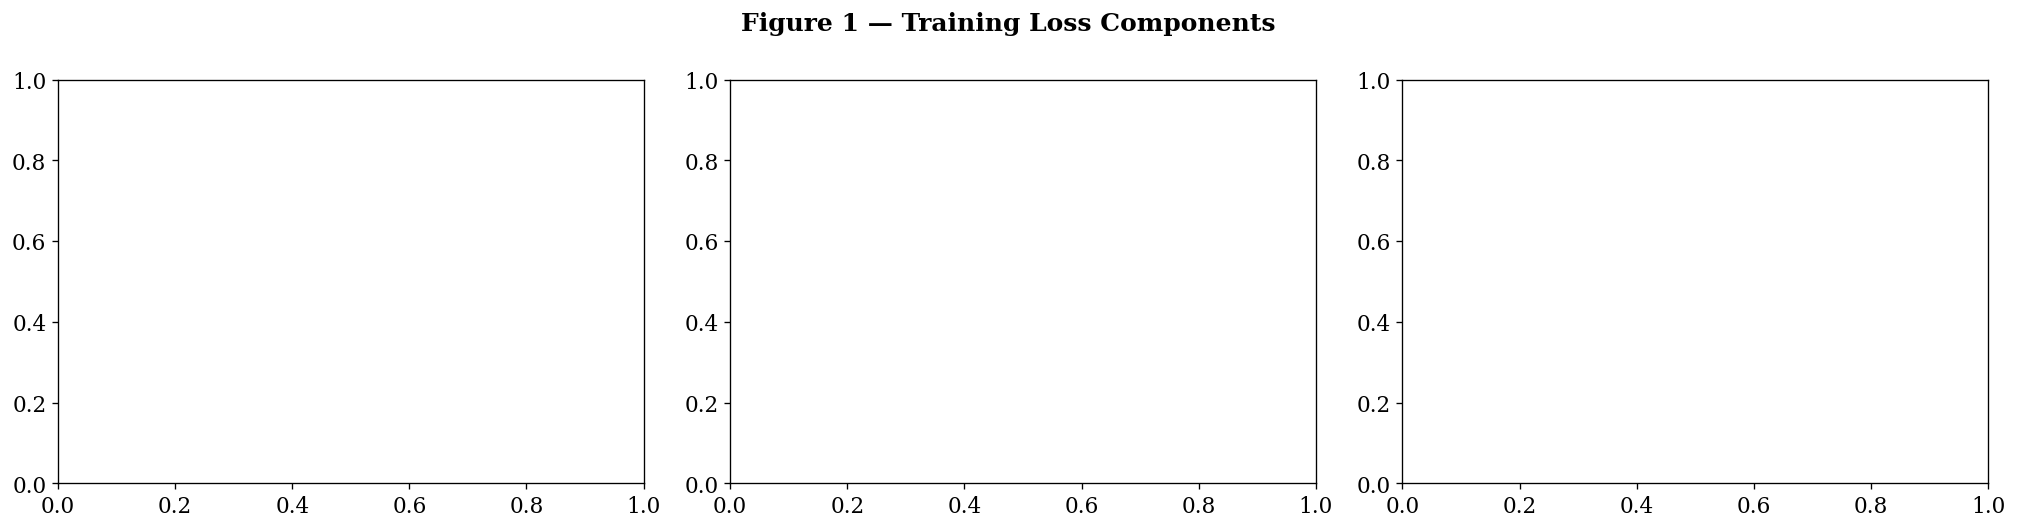

Saved fig1_loss_curves.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, (name, d) in zip(axes, data.items()):
    ep = d['epoch']
    ax.plot(ep, d['loss_total'],   color='#264653', lw=2,   label='Total')
    ax.plot(ep, d['loss_mse'],     color='#2A9D8F', lw=2, ls='--', label='MSE')
    ax.plot(ep, d['loss_physics'], color='#E63946', lw=2, ls=':', label='Physics')
    ax.set_title(LABELS[name], fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.grid(True, ls='--', alpha=0.5); ax.legend()

fig.suptitle('Figure 1 — Training Loss Components', fontsize=15, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig1_loss_curves.png')
plt.show()
print('Saved fig1_loss_curves.png')


### Figure 2: Gradient Norm Ratio ρ (Key result — shows problem & fix)


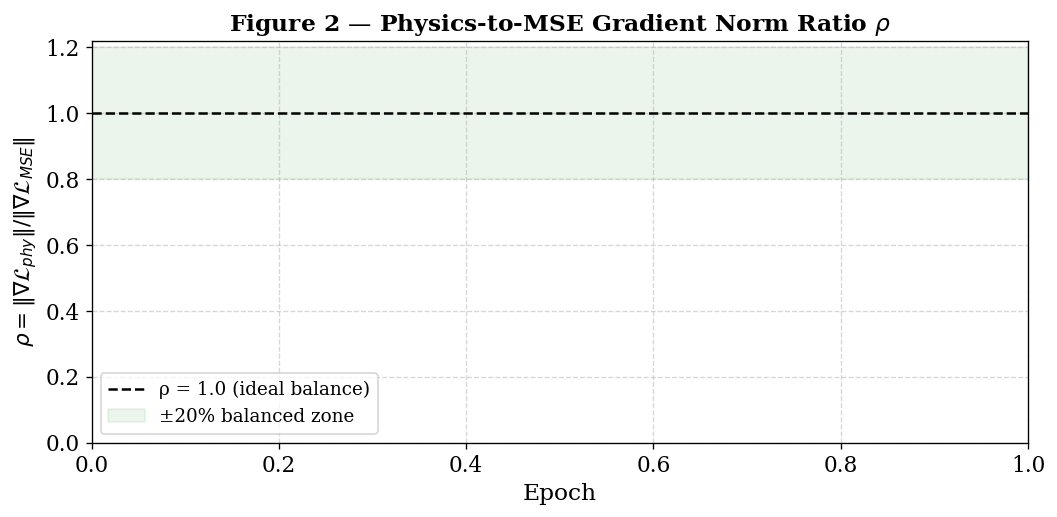

Saved fig2_rho_ratio.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(1.0, color='black', lw=1.5, ls='--', label='ρ = 1.0 (ideal balance)', zorder=5)
ax.axhspan(0.8, 1.2, alpha=0.08, color='green', label='±20% balanced zone')

for name, d in data.items():
    rho = d['rho']
    # Only plot if we have non-zero rho (GNB computes it, others may be 0)
    if any(r > 0 for r in rho):
        ax.plot(d['epoch'], rho, color=COLORS[name], ls=LS[name],
                lw=2.5, label=LABELS[name])

ax.set_xlabel('Epoch')
ax.set_ylabel(r'$\rho = \|\nabla\mathcal{L}_{phy}\| / \|\nabla\mathcal{L}_{MSE}\|$', fontsize=13)
ax.set_title(r'Figure 2 — Physics-to-MSE Gradient Norm Ratio $\rho$', fontweight='bold')
ax.set_ylim(bottom=0); ax.grid(True, ls='--', alpha=0.5); ax.legend()
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig2_rho_ratio.png')
plt.show()
print('Saved fig2_rho_ratio.png')


### Figure 3: λ_phy Schedule


/tmp/ipykernel_752/1965667351.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.grid(True, ls='--', alpha=0.5); ax.legend()


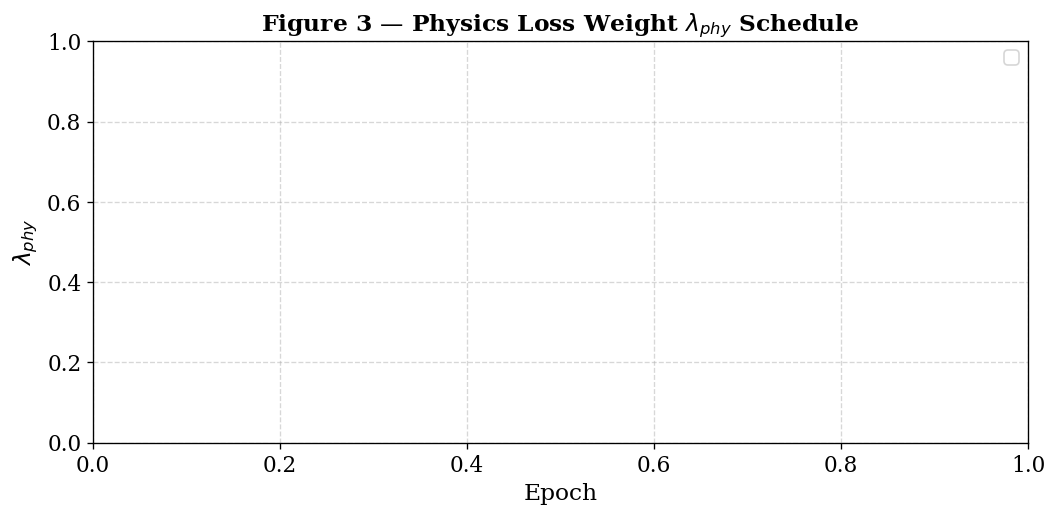

Saved fig3_lambda_schedule.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, d in data.items():
    ax.plot(d['epoch'], d['lambda_phy'], color=COLORS[name], ls=LS[name],
            lw=2.5, label=LABELS[name])
ax.set_xlabel('Epoch')
ax.set_ylabel(r'$\lambda_{phy}$')
ax.set_title(r'Figure 3 — Physics Loss Weight $\lambda_{phy}$ Schedule', fontweight='bold')
ax.grid(True, ls='--', alpha=0.5); ax.legend()
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig3_lambda_schedule.png')
plt.show()
print('Saved fig3_lambda_schedule.png')


### Figure 4-5: RMSE & R² Convergence


/tmp/ipykernel_752/3753551272.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.grid(True, ls='--', alpha=0.5); ax1.legend()
/tmp/ipykernel_752/3753551272.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.grid(True, ls='--', alpha=0.5); ax2.legend()


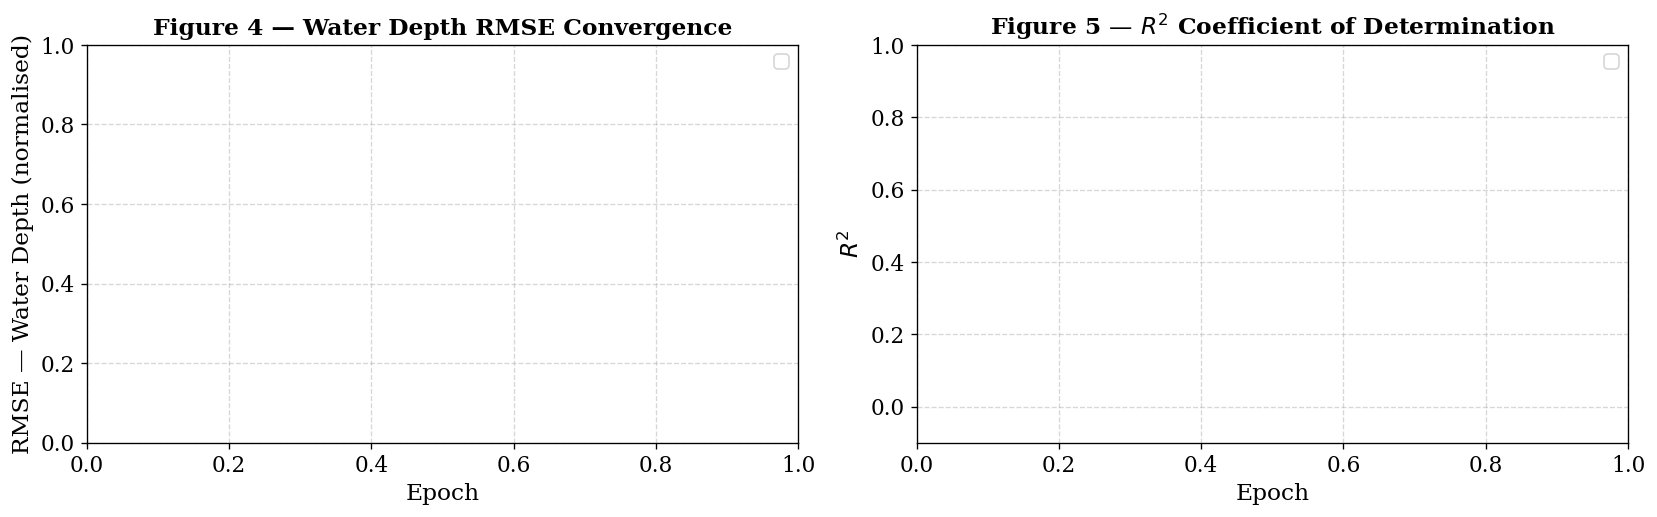

Saved fig45_rmse_r2.png


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

for name, d in data.items():
    ax1.plot(d['epoch'], d['rmse_depth'], color=COLORS[name], ls=LS[name],
             lw=2.5, label=LABELS[name])
    ax2.plot(d['epoch'], d['r2_depth'],   color=COLORS[name], ls=LS[name],
             lw=2.5, label=LABELS[name])

ax1.set_xlabel('Epoch'); ax1.set_ylabel('RMSE — Water Depth (normalised)')
ax1.set_title('Figure 4 — Water Depth RMSE Convergence', fontweight='bold')
ax1.grid(True, ls='--', alpha=0.5); ax1.legend()

ax2.set_xlabel('Epoch'); ax2.set_ylabel(r'$R^2$')
ax2.set_title(r'Figure 5 — $R^2$ Coefficient of Determination', fontweight='bold')
ax2.set_ylim(-0.1, 1.0)
ax2.grid(True, ls='--', alpha=0.5); ax2.legend()

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig45_rmse_r2.png')
plt.show()
print('Saved fig45_rmse_r2.png')


### Figure 6: Final Epoch Summary Bar Chart


ValueError: The number of FixedLocator locations (0), usually from a call to set_ticks, does not match the number of labels (3).

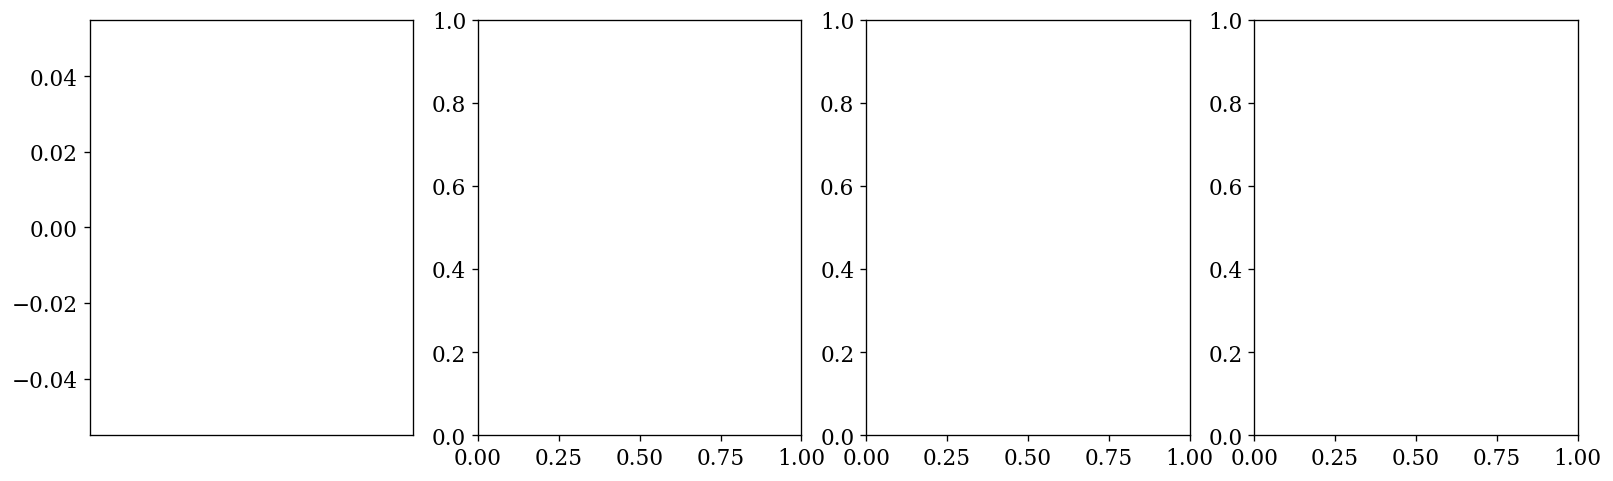

In [17]:
names  = list(data.keys())
x      = np.arange(len(names))
colors = [COLORS[n] for n in names]
labels = [LABELS[n] for n in names]

def last_val(d, key):
    vals = [v for v in d.get(key, [0]) if not math.isnan(v)]
    return vals[-1] if vals else 0.0

rmse_vals = [last_val(data[n], 'rmse_depth')  for n in names]
r2_vals   = [last_val(data[n], 'r2_depth')    for n in names]
lam_vals  = [last_val(data[n], 'lambda_phy')  for n in names]
phy_vals  = [last_val(data[n], 'loss_physics')for n in names]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
specs = [
    (rmse_vals, 'RMSE Depth ↓',         'lower is better'),
    (r2_vals,   r'$R^2$ ↑',             'higher is better'),
    (lam_vals,  r'Final $\lambda_{phy}$',''),
    (phy_vals,  'Final Physics Loss ↓',  'lower is better'),
]
for ax, (vals, ylabel, note) in zip(axes, specs):
    bars = ax.bar(x, vals, color=colors, edgecolor='black', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+abs(bar.get_height())*0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Fixed', 'Warm-up', 'GNB'], fontsize=11)
    ax.set_ylabel(ylabel); ax.set_title(f'{ylabel}\n({note})' if note else ylabel)
    ax.grid(axis='y', ls='--', alpha=0.5)

fig.suptitle('Figure 6 — Final Epoch Metric Comparison', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig6_bar_summary.png')
plt.show()
print('Saved fig6_bar_summary.png')


### ⭐ Figure 7 — Combined Paper Panel (Main Figure)

This is the **main figure for the paper** — a 2×3 panel combining all key results.


In [ ]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]
ax_loss, ax_rho, ax_lam, ax_rmse, ax_r2, ax_bar = axes

# (a) Total loss
for name, d in data.items():
    ax_loss.plot(d['epoch'], d['loss_total'], color=COLORS[name], ls=LS[name], lw=2, label=LABELS[name])
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Total Loss')
ax_loss.set_title('(a) Total Training Loss', fontweight='bold')
ax_loss.grid(True, ls='--', alpha=0.4); ax_loss.legend(fontsize=10)

# (b) rho
ax_rho.axhline(1.0, color='k', lw=1.2, ls='--', label='ρ=1 (ideal)', zorder=5)
ax_rho.axhspan(0.8, 1.2, alpha=0.07, color='green')
for name, d in data.items():
    rho = d['rho']
    if any(r > 0 for r in rho):
        ax_rho.plot(d['epoch'], rho, color=COLORS[name], ls=LS[name], lw=2, label=LABELS[name])
ax_rho.set_xlabel('Epoch')
ax_rho.set_ylabel(r'$\rho = \|\nabla\mathcal{L}_{phy}\|/\|\nabla\mathcal{L}_{MSE}\|$')
ax_rho.set_title(r'(b) Gradient Norm Ratio $\rho$', fontweight='bold')
ax_rho.set_ylim(bottom=0); ax_rho.grid(True, ls='--', alpha=0.4); ax_rho.legend(fontsize=10)

# (c) lambda schedule
for name, d in data.items():
    ax_lam.plot(d['epoch'], d['lambda_phy'], color=COLORS[name], ls=LS[name], lw=2, label=LABELS[name])
ax_lam.set_xlabel('Epoch'); ax_lam.set_ylabel(r'$\lambda_{phy}$')
ax_lam.set_title(r'(c) Physics Loss Weight $\lambda_{phy}$', fontweight='bold')
ax_lam.grid(True, ls='--', alpha=0.4); ax_lam.legend(fontsize=10)

# (d) RMSE
for name, d in data.items():
    ax_rmse.plot(d['epoch'], d['rmse_depth'], color=COLORS[name], ls=LS[name], lw=2, label=LABELS[name])
ax_rmse.set_xlabel('Epoch'); ax_rmse.set_ylabel('RMSE — Water Depth')
ax_rmse.set_title('(d) Depth RMSE Convergence', fontweight='bold')
ax_rmse.grid(True, ls='--', alpha=0.4); ax_rmse.legend(fontsize=10)

# (e) R2
for name, d in data.items():
    ax_r2.plot(d['epoch'], d['r2_depth'], color=COLORS[name], ls=LS[name], lw=2, label=LABELS[name])
ax_r2.set_xlabel('Epoch'); ax_r2.set_ylabel(r'$R^2$')
ax_r2.set_title(r'(e) $R^2$ Coefficient', fontweight='bold')
ax_r2.set_ylim(-0.05, 1.0); ax_r2.grid(True, ls='--', alpha=0.4); ax_r2.legend(fontsize=10)

# (f) Bar summary
names_plot = list(data.keys())
x_b = np.arange(len(names_plot))
bw  = 0.35
rmse_f = [last_val(data[n], 'rmse_depth') for n in names_plot]
r2_f   = [last_val(data[n], 'r2_depth')   for n in names_plot]
bar1 = ax_bar.bar(x_b - bw/2, rmse_f, bw,
                  color=[COLORS[n] for n in names_plot], alpha=0.85, edgecolor='k', label='RMSE↓')
ax_bar2 = ax_bar.twinx()
bar2 = ax_bar2.bar(x_b + bw/2, r2_f, bw,
                   color=[COLORS[n] for n in names_plot], alpha=0.45, edgecolor='k', hatch='///', label=r'$R^2$↑')
for bar, v in zip(bar1, rmse_f):
    ax_bar.text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.3f}', ha='center', fontsize=9)
for bar, v in zip(bar2, r2_f):
    ax_bar2.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=9)
ax_bar.set_xticks(x_b)
ax_bar.set_xticklabels(['Fixed', 'Warm-up', 'GNB'])
ax_bar.set_ylabel('Final RMSE ↓'); ax_bar2.set_ylabel(r'Final $R^2$ ↑')
ax_bar.set_title('(f) Final Epoch Comparison', fontweight='bold')
ax_bar.grid(axis='y', ls='--', alpha=0.4)

fig.suptitle(
    'Adaptive Physics-Constrained Loss Scheduling in KAN-Enhanced GNNs for Flood Forecasting\n'
    'EXP-1: Fixed λ=1.0 (Baseline)  |  EXP-2: Linear Warm-up  |  EXP-3: Gradient Norm Balancing (GNB)',
    fontsize=14, fontweight='bold'
)

fig.savefig(f'{FIG_DIR}/fig7_paper_panel.png', dpi=300)
fig.savefig(f'{FIG_DIR}/fig7_paper_panel.pdf')
plt.show()
print('\nSaved fig7_paper_panel.png  +  fig7_paper_panel.pdf')
print('This is your main paper figure.')


---
## 🔵 CELL 13 — Save Everything to Google Drive

Run this to preserve results (otherwise they are lost when the session ends).


In [ ]:
# Mount Drive first if not already done
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

DRIVE_DIR = '/content/drive/MyDrive/HydroGraphNet_Results'
os.makedirs(DRIVE_DIR, exist_ok=True)

# Copy figures
shutil.copytree('/content/figures',  f'{DRIVE_DIR}/figures',  dirs_exist_ok=True)
# Copy CSVs
shutil.copytree('/content/outputs',  f'{DRIVE_DIR}/outputs',  dirs_exist_ok=True)

# List what was saved
print(f'Saved to Google Drive: {DRIVE_DIR}')
for root, dirs, files in os.walk(DRIVE_DIR):
    level = root.replace(DRIVE_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        size = os.path.getsize(os.path.join(root, f))
        print(f'{indent}  {f}  ({size//1024} KB)')


---
## 🔵 CELL 14 — Download Figures Directly (Alternative)

If you don't use Google Drive, download figures to your local machine.


In [ ]:
from google.colab import files
import os

FIG_DIR = '/content/figures'
for fn in sorted(os.listdir(FIG_DIR)):
    if fn.endswith('.png') or fn.endswith('.pdf'):
        print(f'Downloading: {fn}')
        files.download(f'{FIG_DIR}/{fn}')

# Also download CSVs
for exp in ['fixed', 'linear_warmup', 'gnb']:
    csv_path = f'/content/outputs/{exp}/metrics.csv'
    if os.path.exists(csv_path):
        print(f'Downloading: {exp}/metrics.csv')
        files.download(csv_path)


---
## 📋 Quick Reference

### Files written to `/content/`
| File | Purpose |
|---|---|
| `utils.py` | Physics loss (continuity equation) |
| `adaptive_physics_scheduler.py` | 3 scheduling strategies |
| `train_colab.py` | Main training script (argparse) |
| `data/` | M80 White River dataset (auto-downloaded) |
| `outputs/{exp}/metrics.csv` | Per-epoch training metrics |
| `figures/fig7_paper_panel.pdf` | **Main paper figure** |

### Re-running a single experiment
```bash
# In any code cell:
!python /content/train_colab.py --exp_name fixed --schedule fixed --lambda_init 1.0 --lambda_max 1.0 --epochs 20 --num_samples 15 --out_dir /content/outputs
```

### Increasing training data (more epochs for better results)
Change `EPOCHS = 30` and `NUM_SAMPLES = 30` in Cell 7, then re-run Cells 8–12.

### Paper figure
The file `figures/fig7_paper_panel.pdf` is **camera-ready** at 300 DPI.
